# Construct End-User Particle HDF5 Files

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import h5py
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from pyedm4hep import EDM4hepEvent
from loading_utils import load_root_file

## Roadmap

1. Load in edm4hep file
2. Load in ambi tracks csv 
3. Load in particles root
4. Load in measurements root
5. Load in trackstates ambi root
6. Load in tracksummary ambi root
7. Create track parquet object
8. Track object needs:
    - hits in the track (hit ID)
    - track fit parameters
    - track quality parameters
    - track states at IP, end-of-track, first hit, last hit

# Explore

## 1. Load in edm4hep file

In [19]:
edm4hep_file = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root"
event = EDM4hepEvent(edm4hep_file, event_index=0)

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


## 2. Tidy DF

In [20]:
particles_df = event.get_particles_df()

In [21]:
particles_df

,pdg_id,generator_status,simulator_status,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_tracker_hits,num_calo_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.006138,7000.000000,6999.061730,0,0,False,False,False
1,21,61,0,0.000000,-2.509115,0.000000,0.003355,0.005140,-17.041813,5.048710e-29,...,0.000000,0.006138,0.006138,499.428462,499.428462,0,0,False,False,False
2,2203,63,0,1.333333,-2.509115,0.771330,0.003355,0.005140,-17.041813,0.000000e+00,...,0.000000,0.006138,0.006138,3214.337018,3213.565688,0,0,False,False,False
3,1,63,0,-0.333333,-2.509115,0.330000,0.003355,0.005140,-17.041813,0.000000e+00,...,0.000000,0.006138,0.006138,3286.234560,3285.904560,0,0,False,False,False
4,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.006138,7000.000000,6999.061730,0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701143,2112,0,1426063360,0.000000,12.830523,0.939565,-1039.146086,-239.926026,4026.578817,3.309939e-02,...,-0.705819,1066.484451,1009.493736,0.940824,0.001258,0,5,True,False,False
701144,2112,0,1426063360,0.000000,12.830523,0.939565,-1039.146086,-239.926026,4026.578817,-3.070830e-02,...,-2.498399,1066.484451,1163.133987,0.940773,0.001207,0,9,True,False,False
701145,2112,0,1409286144,0.000000,14.219813,0.939565,-1041.314432,-222.358028,4000.518461,-4.286349e-02,...,-2.708868,1064.790514,1109.645746,0.940758,0.001192,0,10,True,False,False
701146,2112,0,1409286144,0.000000,14.257561,0.939565,-1140.837926,-296.834198,4116.878533,1.534675e-02,...,-1.171358,1178.822173,1064.116793,0.940647,0.001081,0,6,True,False,False


In [22]:
particles_df.reset_index(drop=True, inplace=True)
particles_df["particle_id"] = particles_df.index

In [23]:
particles_df.columns

Index(['pdg_id', 'generator_status', 'simulator_status', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r', 'energy',
       'kinetic_energy', 'num_tracker_hits', 'num_calo_hits',
       'created_in_simulation', 'created_inside_tracker',
       'ended_inside_tracker', 'particle_id'],
      dtype='object')

In [24]:
include_columns = ["particle_id", "pdg_id", "mass", "energy", "charge", "vx", "vy", "vz", "time","px", "py", "pz", "num_tracker_hits", "num_calo_hits"]

In [14]:
# Which particles to include?
# Fixed the query - removed the line break that was causing syntax error
include_query = "(generatorStatus == 0) & (num_tracker_hits > 0) & (num_calo_hits > 0)"

stable_particles = particles_df[particles_df.eval(include_query)]

In [15]:
stable_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_tracker_hits,num_calo_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker
71818,211,0,1157627904,1.0,6.234255,0.139570,10.159487,-193.899007,-1966.534919,-0.391634,...,-3.053597,194.164982,816.014094,0.662493,0.522923,2,66,True,False,False
71953,-11,0,1157627904,1.0,3.084375,0.000511,551.558863,-803.883367,383.607573,0.154126,...,-0.968671,974.908020,1101.228367,0.293060,0.292549,18,13,True,False,False
72048,13,0,1157627904,-1.0,16.098309,0.105658,169.640528,-406.673577,-1029.407742,0.228536,...,-0.143361,440.637387,852.090802,0.266792,0.161134,7,17,True,False,False
72124,-211,0,1157627904,-1.0,2.908499,0.139570,-48.439900,197.837560,967.913551,0.251078,...,-0.515536,203.681428,730.384679,0.875003,0.735433,4,19,True,False,False
72269,-11,0,1426063360,1.0,13.173420,0.000511,253.117936,-198.411218,3200.317293,0.048873,...,-0.610712,321.614211,578.674117,0.087526,0.087015,26,9,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696376,-11,0,1157627904,1.0,-1.607143,0.000511,-111.280826,199.654978,127.437719,-0.288988,...,2.079090,228.572816,1254.672313,0.702588,0.702077,13,1,True,False,False
698184,2112,0,1426063360,0.0,3.485933,0.939565,-392.630188,1270.247291,671.655837,0.017083,...,0.172954,1329.543773,1674.664206,0.941156,0.001590,1,12,True,False,False
699802,-11,0,1157627904,1.0,-1.279373,0.000511,17.438244,-30.251186,349.967999,0.185701,...,-1.042494,34.917425,362.517314,3.884442,3.883931,9,3,True,False,False
700639,-11,0,2030043136,1.0,9.272032,0.000511,-464.393419,-484.202281,3438.706704,0.002896,...,-0.848453,670.904685,434.737377,0.009247,0.008736,6,2,True,False,False


## 3. Convert to HDF5

In [25]:
particles_df.dtypes

pdg_id                      int32
generator_status            int32
simulator_status            int32
charge                    float32
time                      float32
mass                      float64
vx                        float64
vy                        float64
vz                        float64
px                        float64
py                        float64
pz                        float64
endpoint_x                float64
endpoint_y                float64
endpoint_z                float64
parents_begin               int64
parents_end                 int64
daughters_begin             int64
daughters_end               int64
pt                        float64
p                         float64
eta                       float64
phi                       float64
vr                        float64
endpoint_r                float64
energy                    float64
kinetic_energy            float64
num_tracker_hits            int64
num_calo_hits               int64
created_in_sim

In [28]:
particles_to_convert = particles_df[include_columns]

In [32]:
particles_to_convert["event_id"] = 0

/tmp/ipykernel_1073924/2279640384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  particles_to_convert["event_id"] = 0


In [39]:
output_dir = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0"
dataset_name = "full_pileup_mini_pilot.ttbar.v4"
output_file = f"{output_dir}/{dataset_name}.particles.h5"

with h5py.File(output_file, 'a') as f:
    # Create events group if it doesn't exist
    if 'events' not in f:
        events_group = f.create_group('events')
    else:
        events_group = f['events']
        
    # Group DataFrame by event_id
    for event_id, event_df in tqdm(particles_to_convert.groupby('event_id')):
        # Create event group if it doesn't exist
        event_group_name = f'event_{event_id}'
        if event_group_name in events_group:
            # Remove existing group to avoid conflicts
            del events_group[event_group_name]
        event_group = events_group.create_group(event_group_name)
        
        # Store particle data
        event_group.create_dataset(
            'particles',
            data=event_df.drop(columns=['event_id']).to_records(index=False),
            compression="gzip",
            compression_opts=9
        )

100%|██████████| 1/1 [00:11<00:00, 11.13s/it]


In [3]:
## Test Script

from convert_particles import convert_particles

In [5]:
convert_particles(
    input_base_dir="/global/cfs/cdirs/m4958/data/ColliderML/public/",
    output_base_dir="/global/cfs/cdirs/m4958/data/ColliderML/public/",
    dataset_name="full_pileup_mini_pilot/ttbar/v4",
    chunk_size=8,
    run_size=8,
)

2025-08-15 05:26:25,592 - INFO - Processing 1 runs (8 events), 1 runs/chunk, 1 chunks
Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]


Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


Loading event 1 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 842073 particles.
  Loaded 238809 tracker hits.
  Loaded 1213290 calo hits and 5773372 contributions.


Loading event 2 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 836691 particles.
  Loaded 234264 tracker hits.
  Loaded 1198869 calo hits and 5726718 contributions.


Loading event 3 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 927839 particles.
  Loaded 261053 tracker hits.
  Loaded 1311801 calo hits and 6392608 contributions.


Loading event 4 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 828148 particles.
  Loaded 225773 tracker hits.
  Loaded 1153516 calo hits and 5694834 contributions.


Loading event 5 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 1000634 particles.
  Loaded 277940 tracker hits.
  Loaded 1402864 calo hits and 6839004 contributions.


Loading event 6 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 940868 particles.
  Loaded 266801 tracker hits.
  Loaded 1332704 calo hits and 6429712 contributions.


Loading event 7 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 989128 particles.
  Loaded 275536 tracker hits.
  Loaded 1374591 calo hits and 6785985 contributions.




2025-08-15 05:27:09,013 - INFO - Writing 7066529 particles across 8 events -> /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/truth/particles/full_pileup_mini_pilot.ttbar.v4.truth.particles.events0-7.h5
Processing chunks: 100%|██████████| 1/1 [02:36<00:00, 156.26s/it]


# Create Particle Object

In [198]:
def is_physical_particle(row):
    """
    Filter for physically relevant particles:
    - Status 1: Final state stable particle
    - Status 2: Decayed particle that reached the detector
    - Status 4: Beam particle
    """
    # Convert simulatorStatus to int64 for bitwise operations
    sim_status = np.int64(row['simulatorStatus'])
    
    # Stable final state particles
    if row['generatorStatus'] == 1:
        return True
        
    # Check simulator status for particles that interacted with detector
    detector_track = bool(sim_status & np.int64(0x0FF00000))
    
    return detector_track

# First ensure simulatorStatus is numeric
particles_df['simulatorStatus'] = pd.to_numeric(particles_df['simulatorStatus'], errors='coerce')

# Then apply filter
physical_particles_df = particles_df[particles_df.apply(is_physical_particle, axis=1)]

# Let's see what we got
print(f"Total particles: {len(particles_df)}")
print(f"Physical particles: {len(physical_particles_df)}")
print("\nSample of physical particles:")
print(physical_particles_df[['PDG', 'generatorStatus', 'simulatorStatus', 'charge']].head())

Total particles: 406505
Physical particles: 402213

Sample of physical particles:
    PDG  generatorStatus  simulatorStatus  charge
75  211                1         33554432     1.0
76  223                2        134217728     0.0
77 -211                1         33554432    -1.0
78  321                1         33554432     1.0
79 -311                2        134217728     0.0


In [199]:
print("Generator Status distribution:")
print(np.unique(particles_df["generatorStatus"], return_counts=True))

print("\nSimulator Status distribution (most common):")
print(particles_df["simulatorStatus"].value_counts().head(10))

Generator Status distribution:
(array([ 0,  1,  2,  4, 13, 15, 21, 22, 23, 31, 33, 41, 42, 43, 44, 51, 52,
       53, 61, 62, 63, 71, 73], dtype=int32), array([398057,   2768,   1397,     22,      4,      2,     20,      4,
           24,     86,     86,    130,    130,    130,    569,    972,
          437,     49,    106,    701,     47,    557,    207]))

Simulator Status distribution (most common):
simulatorStatus
1493172224    232602
1224736768    146912
1426063360      7961
1157627904      6525
0               4296
1207959552      1531
134217728       1388
1107296256      1351
33554432        1088
150994944       1064
Name: count, dtype: int64


In [36]:
# Neutralinos with mass 2.04229580e+02, pdf id 1000021
particles_df[particles_df.PDG == 1000023][["PDG", "mass", "generatorStatus", "simulatorStatus", "charge", "px", "py", "pz"]]

,PDG,mass,generatorStatus,simulatorStatus,charge,px,py,pz
576,1000023,385.342203,22,0,0.0,576.716797,614.295105,-1494.700317
577,1000023,385.342203,22,0,0.0,-576.716797,-614.295105,-566.135986
645,1000023,385.342203,44,0,0.0,612.710022,652.596802,-1626.515503
646,1000023,385.342203,44,0,0.0,-505.832733,-538.864746,-388.696381
678,1000023,385.342203,44,0,0.0,614.381775,660.740723,-1626.732056
679,1000023,385.342203,44,0,0.0,-505.211823,-535.839966,-391.158447
695,1000023,385.342203,44,0,0.0,621.175171,665.254761,-1624.806030
696,1000023,385.342203,44,0,0.0,-502.688629,-534.163330,-392.868469
725,1000023,385.342203,44,0,0.0,622.416931,666.217529,-1629.668457
726,1000023,385.342203,44,0,0.0,-500.339203,-532.341797,-388.652863


In [34]:
parents_df.iloc[1456]

particle_id            428
collectionID    2714477136
Name: 1456, dtype: int64

In [194]:
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [42]:
particles_with_hits = particles_df.iloc[np.unique(np.concatenate([tracker_df.particle_id.unique(), calo_df.particle_id.unique()]))]

In [52]:
n_hits.particle_id

0          154
1          155
2          159
3          160
4          162
         ...  
1875    158201
1876    163201
1877    176722
1878    178180
1879    181893
Name: particle_id, Length: 1880, dtype: int32

In [53]:
n_hits.n_hits

0       14
1       13
2       12
3       12
4       10
        ..
1875     5
1876     2
1877     1
1878     2
1879     1
Name: n_hits, Length: 1880, dtype: int64

In [9]:
calo_df

,PDG,energy,time,x,y,z,particle_id,detector
0,0,2.416614e-05,312.383392,0.0,0.0,0.0,8352,ECalBarrelCollection
1,0,6.632625e-05,120.258148,0.0,0.0,0.0,8455,ECalBarrelCollection
2,0,7.453639e-05,7668.329590,0.0,0.0,0.0,8592,ECalBarrelCollection
3,0,2.974118e-05,7679.745117,0.0,0.0,0.0,8592,ECalBarrelCollection
4,0,1.697715e-05,7679.745605,0.0,0.0,0.0,8592,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
761504,0,6.907979e-09,4799.214355,0.0,0.0,0.0,1754,HCalEndcapCollection
761505,0,2.598804e-04,24.107910,0.0,0.0,0.0,1754,HCalEndcapCollection
761506,0,4.960612e-05,24.099184,0.0,0.0,0.0,1754,HCalEndcapCollection
761507,0,5.468227e-05,24.303453,0.0,0.0,0.0,1754,HCalEndcapCollection


In [18]:
# Group the tracker DataFrame by particle_id to count hits
n_tracker_hits = tracker_df.groupby("particle_id").size().reset_index(name="n_tracker_hits")
n_calo_hits = calo_df.groupby("particle_id").size().reset_index(name="n_calo_hits")


# Set particle_id as index in particles_df and initialize n_hits to 0
particles_df["n_tracker_hits"] = 0
particles_df["n_calo_hits"] = 0
# Update n_hits using .loc to align on the index (particle_id)
particles_df.loc[n_tracker_hits["particle_id"], "n_tracker_hits"] = n_tracker_hits["n_tracker_hits"].values
particles_df.loc[n_calo_hits["particle_id"], "n_calo_hits"] = n_calo_hits["n_calo_hits"].values

In [13]:
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'particle_id',
       'n_tracker_hits', 'n_calo_hits', 'n_hits'],
      dtype='object')

In [21]:
full_particles_columns = [
    "particle_id",
    "PDG",
    "mass",
    "charge",
    "vx",
    "vy",
    "vz",
    "px",
    "py",
    "pz",
    "n_tracker_hits",
    "n_calo_hits",
]
full_particle_df = particles_df[full_particles_columns].rename(columns={"PDG": "pdg_id"})
full_particle_df.head()

,particle_id,pdg_id,mass,charge,vx,vy,vz,px,py,pz,n_tracker_hits,n_calo_hits
0,0,2212,0.93827,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7000.000000,0,0
1,1,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,2.672720,-0.225431,2607.456299,0,0
2,2,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,-0.115590,-0.485282,376.884857,0,0
3,3,21,0.00000,0.000000,0.003543,-0.005813,-105.372111,-0.391733,-1.676179,267.835968,0,0
4,4,1,0.00000,-0.333333,0.003543,-0.005813,-105.372111,3.310610,0.479107,155.346054,0,0


<Axes: xlabel='n_tracker_hits', ylabel='Count'>

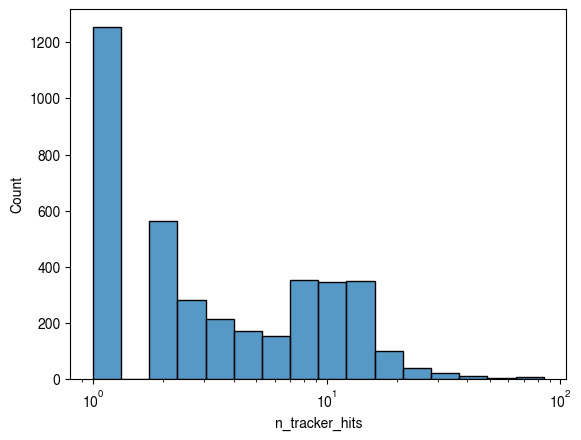

In [24]:
sns.histplot(full_particle_df.n_tracker_hits, log_scale=True)

<Axes: xlabel='n_calo_hits', ylabel='Count'>

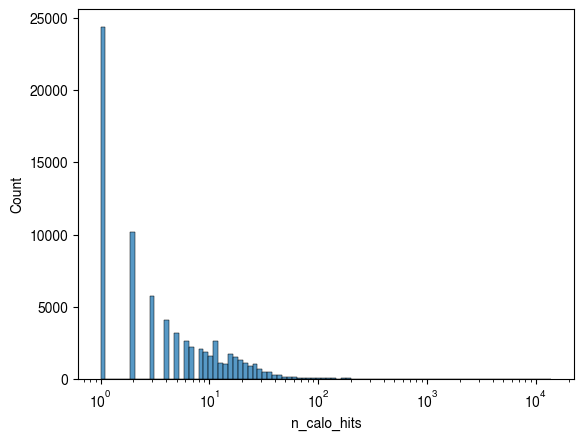

In [25]:
sns.histplot(full_particle_df.n_calo_hits, log_scale=True)

In [26]:
full_particle_df.n_tracker_hits.describe(), full_particle_df.n_calo_hits.describe()

(count    406505.000000
 mean          0.054280
 std           0.857271
 min           0.000000
 25%           0.000000
 50%           0.000000
 75%           0.000000
 max          85.000000
 Name: n_tracker_hits, dtype: float64,
 count    406505.000000
 mean          1.873308
 std          37.631502
 min           0.000000
 25%           0.000000
 50%           0.000000
 75%           0.000000
 max       13915.000000
 Name: n_calo_hits, dtype: float64)

## Process all events

In [ ]:
def process_event_for_particles(
    event_id: int,
    particles_df: pd.DataFrame,
    tracker_df: pd.DataFrame,
    calo_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Process particle data for a single event.
    
    Args:
        event_id: Event number
        particles_df: DataFrame containing particle information
        tracker_df: DataFrame containing tracker hits
        calo_df: DataFrame containing calorimeter hits
        
    Returns:
        DataFrame containing particle data for this event
    """
    # Count hits per particle
    n_tracker_hits = tracker_df.groupby("particle_id").size().reset_index(name="n_tracker_hits")
    n_calo_hits = calo_df.groupby("particle_id").size().reset_index(name="n_calo_hits")
    
    # Select relevant columns
    particle_columns = [
        "particle_id",
        "PDG",
        "mass",
        "charge",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "endpoint_x", "endpoint_y", "endpoint_z",
    ]
    
    event_particles = particles_df[particle_columns].copy()
    
    # Add hit counts
    event_particles = event_particles.merge(
        n_tracker_hits, on="particle_id", how="left"
    ).merge(
        n_calo_hits, on="particle_id", how="left"
    )
    
    # Fill NaN hit counts with 0
    event_particles["n_tracker_hits"] = event_particles["n_tracker_hits"].fillna(0)
    event_particles["n_calo_hits"] = event_particles["n_calo_hits"].fillna(0)
    
    # Add event_id
    event_particles["event_id"] = event_id
    
    # Rename columns to match convention
    event_particles = event_particles.rename(columns={
        "PDG": "pdg_id",
    })
    
    return event_particles

def build_hdf5_particles(
    df: pd.DataFrame,
    output_file: str
) -> None:
    """
    Build HDF5 file with event/particle hierarchy.
    
    Structure:
    /events/
        /event_0/
            /particles    # Dataset containing particle properties
        /event_1/
            ...
            
    Args:
        df: DataFrame containing particle data
        output_file: Path to output HDF5 file
    """
    with h5py.File(output_file, 'a') as f:
        # Create events group if it doesn't exist
        if 'events' not in f:
            events_group = f.create_group('events')
        else:
            events_group = f['events']
            
        # Group DataFrame by event_id
        for event_id, event_df in df.groupby('event_id'):
            # Create event group
            event_group = events_group.create_group(f'event_{event_id}')
            
            # Store particle data
            event_group.create_dataset(
                'particles',
                data=event_df.drop(columns=['event_id']).to_records(index=False),
                compression="gzip",
                compression_opts=9
            )

def process_full_dataset_for_particles(
    base_dir: str,
    output_base_dir: str,
    chunk_size: int = 1000,
    run_size: int = 10,
    dataset_name: str = "pileup-10/ttbar/v1/reco/particles/"
) -> None:
    """
    Process entire dataset in chunks.
    
    Args:
        base_dir: Base directory containing all runs
        output_dir: Directory to save HDF5 files
        chunk_size: Number of events per chunk/file
        dataset_name: Name of the dataset (used in filename)
    """
    # Get properly sorted run directories
    run_dirs = get_run_paths(base_dir)
    num_runs = len(run_dirs)
    num_events = num_runs * run_size
    
    # Calculate runs per chunk
    runs_per_chunk = chunk_size // run_size
    
    print(f"Processing {num_runs} runs with {num_events} total events")
    print(f"Processing {runs_per_chunk} runs per chunk to get ~{chunk_size} events per file")
    
    output_dir = f"{output_base_dir}/{dataset_name}"
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    dataset_name = dataset_name.replace("/", ".")
    
    # Process chunks of runs
    for start_run in tqdm(range(0, num_runs, runs_per_chunk), desc="Processing chunks"):
        all_events_data = []
        
        # Process each run in the chunk
        for run_idx in range(start_run, min(start_run + runs_per_chunk, len(run_dirs))):
            run_dir = run_dirs[run_idx]
            print(f"Processing run {run_idx} at {run_dir}")
            
            # Load EDM4HEP file for this run
            edm4hep_file = f"{run_dir}/edm4hep.root"
            event = load_edm4hep_file(edm4hep_file, event_num=0)
            
            # Process event
            event_df = process_event_for_particles(
                run_idx * run_size,
                event["particles_df"],
                event["tracker_df"],
                event["calo_contrib_df"]
            )
            all_events_data.append(event_df)
            
        if all_events_data:
            combined_df = pd.concat(all_events_data, ignore_index=True)
            
            # Calculate event range for filename
            start_event = start_run * run_size
            end_event = min((start_run + runs_per_chunk) * run_size - 1, 
                           len(run_dirs) * run_size - 1)
            
            output_file = f"{output_dir}/{dataset_name}.events{start_event}-{end_event}.h5"
            build_hdf5_particles(combined_df, output_file)
            print(f"Saved {output_file}")